# **Capítulo 4: Series de Tiempo.  Caso de Estudio 1: Clima**

```
Libro: Investigación en Ciencia de Datos
```

**Autora:** Dora María Ballesteros  
Universidad Militar Nueva Granada (UMNG)

---


### Material complementario del libro

Este notebook acompaña el **Capítulo 4** del libro y desarrolla el **Caso de Estudio 1: Clima**, incluyendo los ejemplos, análisis y experimentos presentados a lo largo del capítulo.

Se recomienda seguir el mismo orden del libro para obtener el máximo provecho de las actividades propuestas.


# **0. LECTURA Y PRE-VISUALIZACIÓN DEL DATASET**

**LECTURA  DEL DATASET CLIMA**

In [1]:
import pandas as pd

In [2]:
clima_df = pd.read_csv("/content/clima.csv")

clima_df.head()

,tiempo_hora_local,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima
0,01-10-2019 00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
1,01-10-2019 01:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2,01-10-2019 02:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
3,01-10-2019 03:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
4,01-10-2019 04:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night


**INFO: TIPO DE VARIABLES, CANTIDAD DE FILAS, DATOS NO NULOS**

In [3]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tiempo_hora_local         499 non-null    object 
 1   temperatura               499 non-null    float64
 2   humedad                   499 non-null    float64
 3   punto_rocio               499 non-null    float64
 4   direccion_viento          499 non-null    float64
 5   velocidad_viento          499 non-null    float64
 6   rafagas_viento            499 non-null    float64
 7   presion                   499 non-null    float64
 8   indice_UV                 499 non-null    float64
 9   ozono                     499 non-null    float64
 10  intensidad_precipitacion  499 non-null    float64
 11  estado_clima              499 non-null    object 
dtypes: float64(10), object(2)
memory usage: 60.9+ KB


**ELIMINA FILAS CON DATOS VACÍOS EN LA COLUMNA ESTADO_CLIMA (DATO A PREDECIR)**

In [4]:
clima_df = clima_df.dropna(subset=['estado_clima'])

**VERIFICACIÓN DEL DATASET DESPUÉS DE DROPNA**

In [5]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 498
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   tiempo_hora_local         499 non-null    object 
 1   temperatura               499 non-null    float64
 2   humedad                   499 non-null    float64
 3   punto_rocio               499 non-null    float64
 4   direccion_viento          499 non-null    float64
 5   velocidad_viento          499 non-null    float64
 6   rafagas_viento            499 non-null    float64
 7   presion                   499 non-null    float64
 8   indice_UV                 499 non-null    float64
 9   ozono                     499 non-null    float64
 10  intensidad_precipitacion  499 non-null    float64
 11  estado_clima              499 non-null    object 
dtypes: float64(10), object(2)
memory usage: 50.7+ KB


# **1. EDA EN EL DATASET CLIMA**

**CONVERSIÓN DE FORMATO DE LA COLUMNA DE TIEMPO**

In [6]:

clima_df['tiempo_hora_local'] = pd.to_datetime(clima_df['tiempo_hora_local'], format='%d-%m-%Y %H:%M')

clima_df.head()

,tiempo_hora_local,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima
0,2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
1,2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2,2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
3,2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
4,2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night


**VERIFICACIÓN DEL TIPO DE DATOS DESPUÉS DE LA CONVERSIÓN**

In [7]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 499 entries, 0 to 498
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   tiempo_hora_local         499 non-null    datetime64[ns]
 1   temperatura               499 non-null    float64       
 2   humedad                   499 non-null    float64       
 3   punto_rocio               499 non-null    float64       
 4   direccion_viento          499 non-null    float64       
 5   velocidad_viento          499 non-null    float64       
 6   rafagas_viento            499 non-null    float64       
 7   presion                   499 non-null    float64       
 8   indice_UV                 499 non-null    float64       
 9   ozono                     499 non-null    float64       
 10  intensidad_precipitacion  499 non-null    float64       
 11  estado_clima              499 non-null    object        
dtypes: datetime64[ns](1), float

**ASIGNACIÓN DE LA COLUMNA TEMPORAL COMO ÍNDICE DEL DATAFRAME**

In [8]:
# Asignación de la columna temporal como índice del dataframe
clima_df = clima_df.set_index('tiempo_hora_local')

# Ordenar por índice temporal (buena práctica en series de tiempo)
clima_df = clima_df.sort_index()

In [9]:
clima_df.head()

,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,partly-cloudy-night
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,partly-cloudy-night
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,partly-cloudy-night
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,partly-cloudy-night
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,partly-cloudy-night


**IDENTIFICACIÓN DE LAS OPCIONES DENTRO DE LA COLUMNA ESTADO_CLIMA**

In [10]:
unicos_clima = clima_df['estado_clima'].unique()
print(unicos_clima)

['partly-cloudy-night' 'partly-cloudy-day' 'clear-night' 'clear-day'
 'cloudy']


**CREAR DICCIONARIO Y ASIGNAR VALORES NUMÉRICOS A LOS VALORES ÚNICOS DE LA COLUMNA ESTADO_CLIMA**




*   clear-day (día despejado) → 1
*   clear-night (noche despejada) → 2
*   partly-cloudy-day (parcialmente nublado de día) → 3
*   partly-cloudy-night (parcialmente nublado de noche) → 4
*   cloudy (nublado) → 5



In [11]:
# Diccionario de codificación del estado del clima
clima_dict = {
    'clear-day': 1,
    'clear-night': 2,
    'partly-cloudy-day': 3,
    'partly-cloudy-night': 4,
    'cloudy': 5
}

# Codificación de la variable de salida
clima_df['estado_clima_enc'] = clima_df['estado_clima'].map(clima_dict)


# Verificar que no existan valores sin codificar
print("Valores no codificados:",
      clima_df['estado_clima_enc'].isna().sum())

# Eliminar la columna "estado_clima"
del clima_df['estado_clima']

clima_df.head()

Valores no codificados: 0


,temperatura,humedad,punto_rocio,direccion_viento,velocidad_viento,rafagas_viento,presion,indice_UV,ozono,intensidad_precipitacion,estado_clima_enc
tiempo_hora_local,,,,,,,,,,,
2019-10-01 00:00:00,26.0,1.0,22.01,101.0,3.08,6.42,1008.45,0.0,268.6,0.0,4
2019-10-01 01:00:00,25.0,1.0,22.06,105.0,2.94,6.28,1008.24,0.0,269.1,0.0,4
2019-10-01 02:00:00,25.0,1.0,22.06,106.0,2.82,6.08,1007.90,0.0,269.7,0.0,4
2019-10-01 03:00:00,24.0,1.0,21.87,106.0,2.63,5.74,1007.61,0.0,270.4,0.0,4
2019-10-01 04:00:00,23.0,1.0,21.53,100.0,2.39,5.30,1007.51,0.0,271.3,0.0,4


In [12]:
clima_df.index

DatetimeIndex(['2019-10-01 00:00:00', '2019-10-01 01:00:00',
               '2019-10-01 02:00:00', '2019-10-01 03:00:00',
               '2019-10-01 04:00:00', '2019-10-01 05:00:00',
               '2019-10-01 06:00:00', '2019-10-01 07:00:00',
               '2019-10-01 08:00:00', '2019-10-01 09:00:00',
               ...
               '2019-10-21 09:00:00', '2019-10-21 10:00:00',
               '2019-10-21 11:00:00', '2019-10-21 12:00:00',
               '2019-10-21 13:00:00', '2019-10-21 14:00:00',
               '2019-10-21 15:00:00', '2019-10-21 16:00:00',
               '2019-10-21 17:00:00', '2019-10-21 18:00:00'],
              dtype='datetime64[ns]', name='tiempo_hora_local', length=499, freq=None)

In [13]:
clima_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 499 entries, 2019-10-01 00:00:00 to 2019-10-21 18:00:00
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   temperatura               499 non-null    float64
 1   humedad                   499 non-null    float64
 2   punto_rocio               499 non-null    float64
 3   direccion_viento          499 non-null    float64
 4   velocidad_viento          499 non-null    float64
 5   rafagas_viento            499 non-null    float64
 6   presion                   499 non-null    float64
 7   indice_UV                 499 non-null    float64
 8   ozono                     499 non-null    float64
 9   intensidad_precipitacion  499 non-null    float64
 10  estado_clima_enc          499 non-null    int64  
dtypes: float64(10), int64(1)
memory usage: 46.8 KB


# **2. ENTRENAMIENTO DEL MODELO ANTES DE FE**

**CANTIDAD DE DATOS PARA CADA OPCIÓN DE LA COLUMNA ESTADO_CLIMA_ENC**

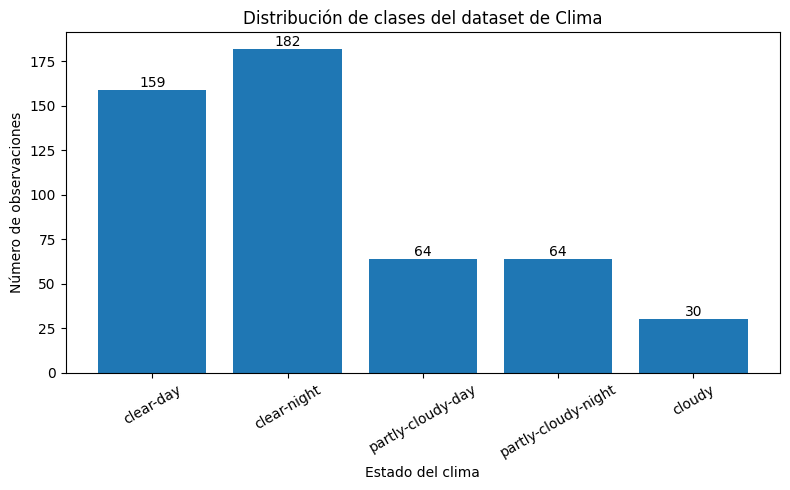

In [14]:
import matplotlib.pyplot as plt

# Diccionario inverso (número → nombre)
inv_clima_dict = {v: k for k, v in clima_dict.items()}

# Conteo por clase
counts = (
    clima_df["estado_clima_enc"]
    .value_counts()
    .sort_index()
    .rename(index=inv_clima_dict)
)

# Gráfica
plt.figure(figsize=(8,5))
bars = plt.bar(
    counts.index,
    counts.values
)

# Etiquetas encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{int(height)}",
        ha="center",
        va="bottom"
    )

plt.xlabel("Estado del clima")
plt.ylabel("Número de observaciones")
plt.title("Distribución de clases del dataset de Clima")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**EVOLUCIÓN TEMPORAL DE LAS VARIABLES CLIMÁTICAS**

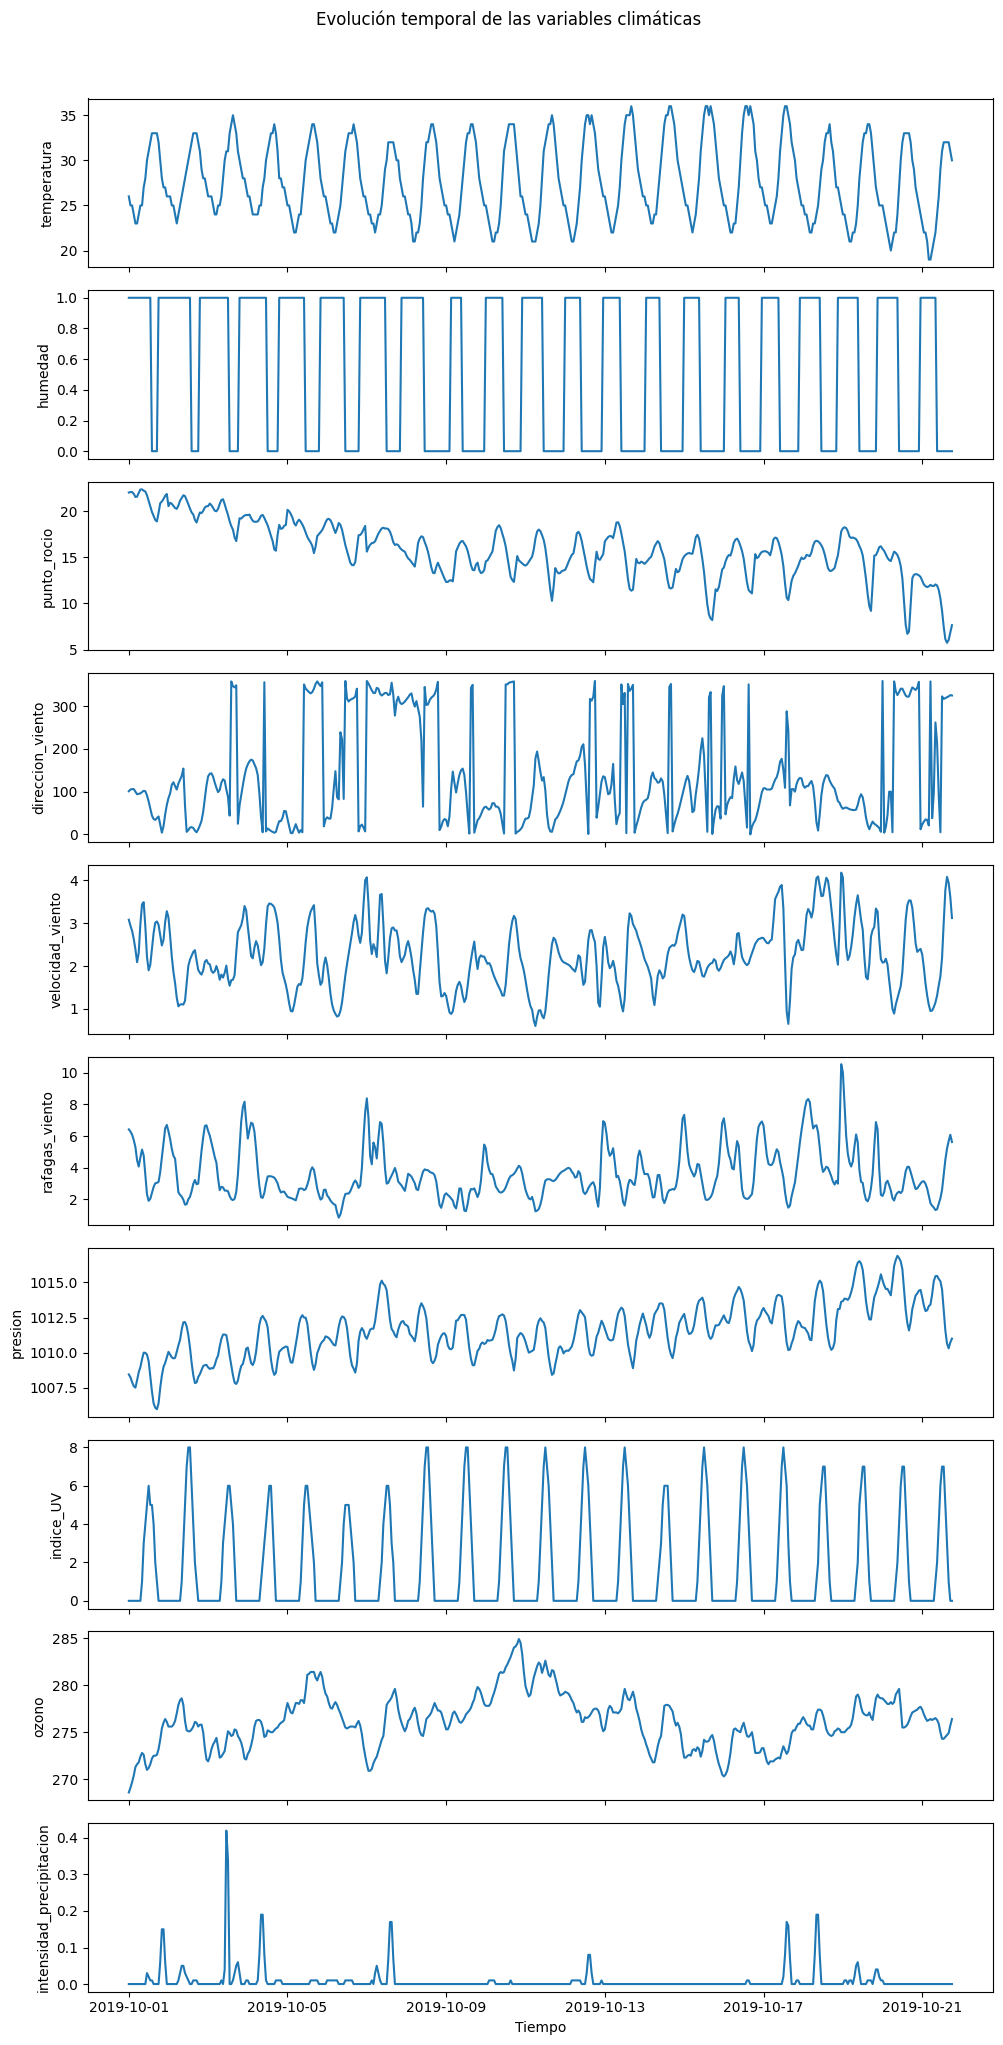

In [15]:
features = clima_df.drop(columns=["estado_clima_enc"]).columns

fig, axes = plt.subplots(len(features), 1, figsize=(10, 2*len(features)), sharex=True)

for ax, col in zip(axes, features):
    ax.plot(clima_df.index, clima_df[col])
    ax.set_ylabel(col)

axes[-1].set_xlabel("Tiempo")
fig.suptitle("Evolución temporal de las variables climáticas", y=1.02)
plt.tight_layout()
plt.show()


**ENTRENAMIENTO DE UN MODELO TIPO RANDOMFOREST MULTI-CLASE**

Accuracy:  0.6867
Precision: 0.6549
Recall:    0.6867
F1-score:  0.6589

Classification Report:
               precision    recall  f1-score   support

           1       0.93      0.78      0.85        68
           2       0.62      0.89      0.74        56
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23
           5       0.00      0.00      0.00         0

    accuracy                           0.69       150
   macro avg       0.31      0.33      0.32       150
weighted avg       0.65      0.69      0.66       150



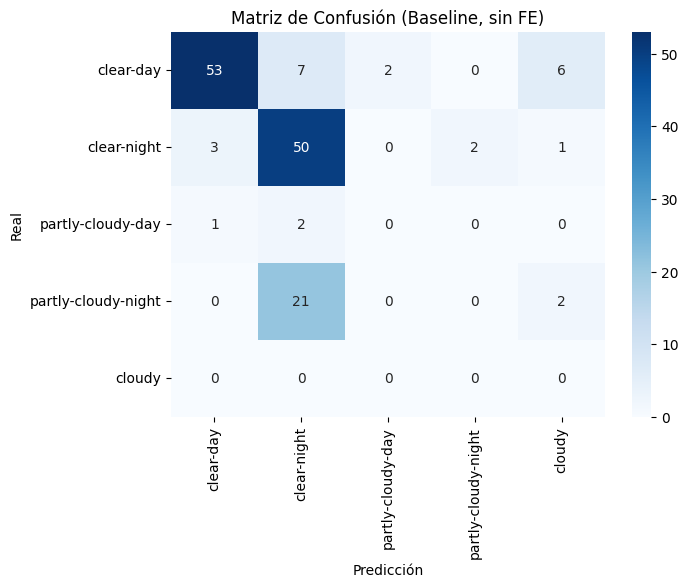

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# =========================
# 1) Definir X e y
# =========================
X = clima_df.drop(columns=["estado_clima_enc"], errors="ignore")
y = clima_df["estado_clima_enc"]  # objetivo multiclase (1..5)

# =========================
# 2) Split temporal (70%-30%)
# =========================
split = int(len(clima_df) * 0.7)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# =========================
# 3) Entrenar modelo (baseline sin FE)
# =========================
clf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)
clf.fit(X_train, y_train)

# =========================
# 4) Predicción
# =========================
y_pred = clf.predict(X_test)

# =========================
# 5) Métricas
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# =========================
# 6) Matriz de confusión
# =========================
labels_num = [1, 2, 3, 4, 5]
labels_txt = ['clear-day', 'clear-night', 'partly-cloudy-day', 'partly-cloudy-night', 'cloudy']

conf_matrix = confusion_matrix(y_test, y_pred, labels=labels_num)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_txt,
    yticklabels=labels_txt
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Baseline, sin FE)")
plt.show()


# **3. FEATURE ENGINEERING (CONSTRUCCIÓN DE NUEVAS CARACTERÍSTICAS)**

**MATRIZ DE CORRELACIÓN ENTRE VARIABLES CLIMÁTICAS**

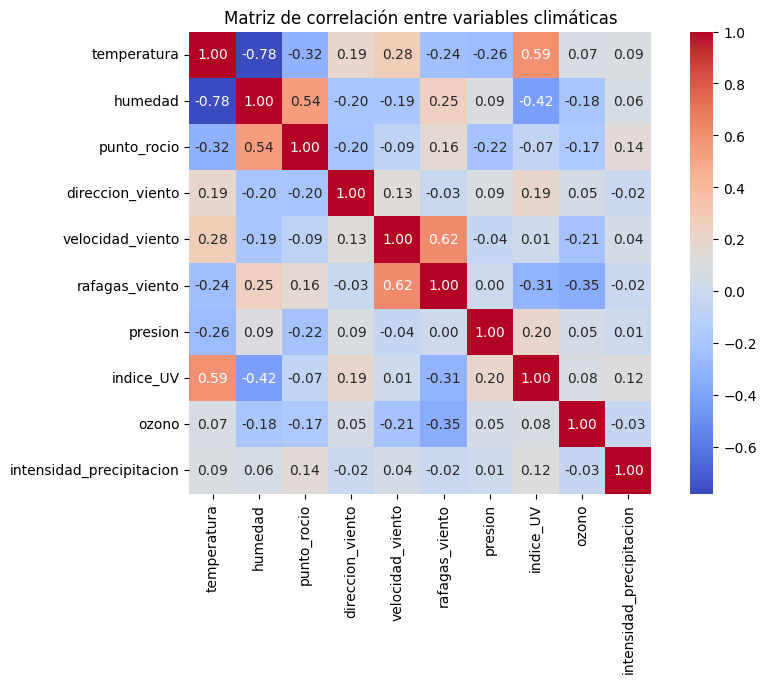

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar solo variables numéricas
corr_matrix = clima_df.drop(columns=['estado_clima_enc']).corr()

# Graficar heatmap de correlación
plt.figure(figsize=(10, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    square=True
)
plt.title("Matriz de correlación entre variables climáticas")
plt.show()

**CREACIÓN DE NUEVOS FEATURES TIPO: LAG, ROLLING, EXPANDING**

In [18]:
import pandas as pd

# Asegurar orden temporal (muy importante para lags/rolling/expanding)
clima_df = clima_df.sort_index()

# Copia para crear features sin tocar el original
clima_fe = clima_df.copy()

# -----------------------------
# 1) Lag features (retardos)
# -----------------------------
fe_cols = ["temperatura", "humedad", "indice_UV", "punto_rocio"]
sizes = [1, 2, 3]  # horas

for col in fe_cols:
    for s in sizes:
        clima_fe[f"{col}_lag{s}"] = clima_fe[col].shift(s)

# -----------------------------
# 2) Rolling features (ventanas móviles)
# -----------------------------
windows = [3, 6]  # horas

for col in fe_cols:
    for w in windows:
        clima_fe[f"{col}_roll_mean_{w}h"] = clima_fe[col].rolling(window=w).mean()
        clima_fe[f"{col}_roll_std_{w}h"]  = clima_fe[col].rolling(window=w).std()
        clima_fe[f"{col}_roll_min_{w}h"]  = clima_fe[col].rolling(window=w).min()
        clima_fe[f"{col}_roll_max_{w}h"]  = clima_fe[col].rolling(window=w).max()

# -----------------------------
# 3) Expanding features (acumuladas)
# -----------------------------
for col in fe_cols:
    clima_fe[f"{col}_exp_mean"] = clima_fe[col].expanding().mean()
    clima_fe[f"{col}_exp_max"]  = clima_fe[col].expanding().max()

# -----------------------------
# 4) Limpieza por NaNs creados por lags/rolling
# -----------------------------
clima_fe = clima_fe.dropna().copy()

# -----------------------------
# 5) Separar X e y (listo para modelamiento con FE)
# -----------------------------
X_fe = clima_fe.drop(columns=["estado_clima_enc"], errors="ignore")
y_fe = clima_fe["estado_clima_enc"]

print("Shape original:", clima_df.shape)
print("Shape con FE:", clima_fe.shape)
print("Nuevas columnas creadas:", X_fe.shape[1] - (clima_df.shape[1] - 1))


Shape original: (499, 11)
Shape con FE: (494, 63)
Nuevas columnas creadas: 52


**PREPARACIÓN DEL DATASET (SPLIT) Y ENTRENAMIENTO DEL MODELO**

Resultados del modelo con Feature Engineering

Accuracy:  0.7987
Precision: 0.6859
Recall:    0.7987
F1-score:  0.7310

Classification Report:

              precision    recall  f1-score   support

           1       0.95      0.94      0.95        67
           2       0.68      1.00      0.81        56
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00        23

    accuracy                           0.80       149
   macro avg       0.41      0.49      0.44       149
weighted avg       0.69      0.80      0.73       149



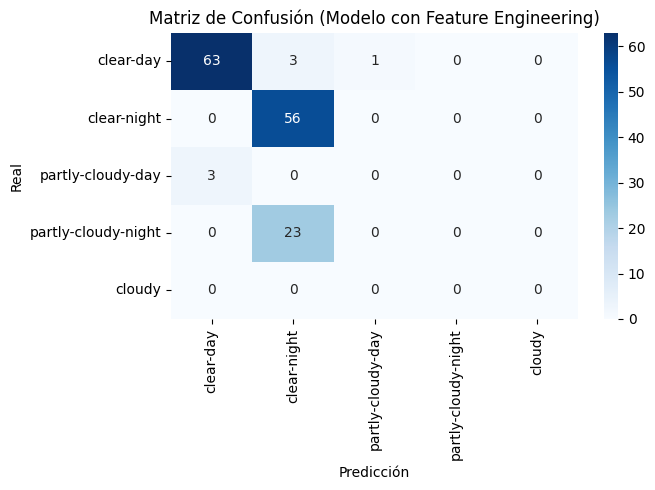

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

# =========================
# 1) Definir X e y (con FE)
# =========================
X = X_fe.copy()
y = y_fe.copy()   # objetivo multiclase (1..5)

# =========================
# 2) Split temporal (70%-30%)
# =========================
split = int(len(X) * 0.7)

X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# =========================
# 3) Entrenar modelo (con FE)
# =========================
clf_fe = RandomForestClassifier(
    n_estimators=100,          #
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

clf_fe.fit(X_train, y_train)

# =========================
# 4) Predicción
# =========================
y_pred = clf_fe.predict(X_test)

# =========================
# 5) Métricas
# =========================
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print("Resultados del modelo con Feature Engineering\n")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, zero_division=0))

# =========================
# 6) Matriz de confusión
# =========================
labels_num = [1, 2, 3, 4, 5]
labels_txt = [
    "clear-day",
    "clear-night",
    "partly-cloudy-day",
    "partly-cloudy-night",
    "cloudy"
]

conf_matrix = confusion_matrix(y_test, y_pred, labels=labels_num)

plt.figure(figsize=(7, 5))
sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_txt,
    yticklabels=labels_txt
)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (Modelo con Feature Engineering)")
plt.tight_layout()
plt.show()


**IMPORTANCIA DE CADA FEATURE EN EL MODELO**

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

# Obtener importancias
importances = clf_fe.feature_importances_

# Crear DataFrame
feature_importance_df = pd.DataFrame({
    "feature": X_fe.columns,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Mostrar las 15 más importantes
feature_importance_df.head(15)


,feature,importance
60,punto_rocio_exp_mean,0.071312
56,humedad_exp_mean,0.044725
54,temperatura_exp_mean,0.040187
41,indice_UV_roll_max_3h,0.037831
52,punto_rocio_roll_min_6h,0.036266
8,ozono,0.035445
53,punto_rocio_roll_max_6h,0.034971
6,presion,0.032187
38,indice_UV_roll_mean_3h,0.029419
58,indice_UV_exp_mean,0.029404


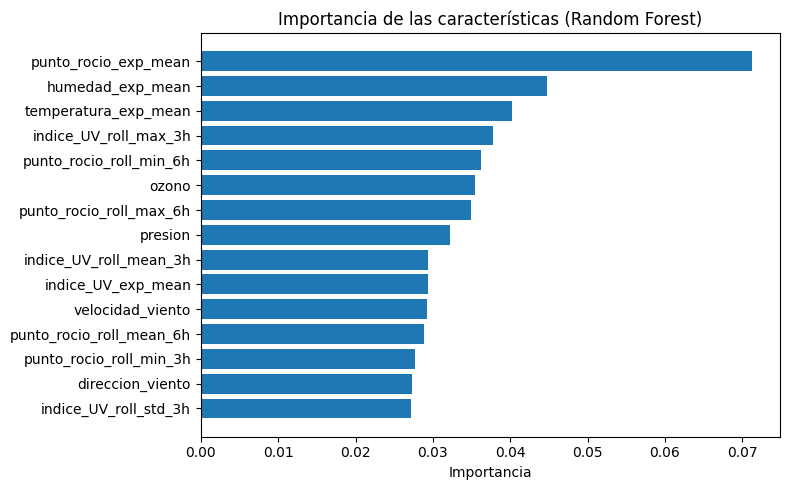

In [21]:
plt.figure(figsize=(8,5))

top_n = 15
plt.barh(
    feature_importance_df["feature"].head(top_n)[::-1],
    feature_importance_df["importance"].head(top_n)[::-1]
)

plt.xlabel("Importancia")
plt.title("Importancia de las características (Random Forest)")
plt.tight_layout()
plt.show()


Libro: Investigación en Ciencia de Datos

---


Versión: 2026 – Material complementario para Google Colab.